In [2]:
import numpy as np
import pandas as pd

In [3]:
df_cleaned = pd.read_excel('../data/cleaned_student_performance_dataset.xlsx') # Let's load the cleaned data from our exported file

In [4]:
df_cleaned['Total_Academic'] = (
    df_cleaned['Midterm'] +
    df_cleaned['Assignments'] * 5 +
    df_cleaned['Quizzes'] * 2 
)
# Creating a new column/feature in the cleaned dataFrame using the data already present in it

In [5]:
df_cleaned['Attendance_Category'] = pd.cut(
    df_cleaned['Attendance_%'],
    bins = [0, 60, 80, 100],
    labels = ['Low', 'Medium', 'High']
)
# Creating a new column/feature using the cut() method of pandas using numbers 
# and giving labels to the specified values which align with the bins provided

In [6]:
# Manual Processing
 
 # df_encoded = pd.get_dummies(df_cleaned, columns=['Gender', 'Internet_Access', 'City', 'Department'], drop_first=True)
 #  Using one-Hot encoding for the encoding of these columns since, as mentioned in the project.pdf, there's no order in the data they hold so 
 #  they all should be one-Hot encoded since it's most suitable for this type of data.

 # from sklearn.preprocessing import OrdinalEncoder
 # encoder = OrdinalEncoder(categories=[['Intermediate', 'Bachelors', 'Masters']])
 # df_encoded['Education_Encoded'] = encoder.fit_transform(df_encoded[['Education_Level']])
 # Using ordinal encoder from the sklearn library to encode the Education_Level column into a separate encoded column
 # with the order being Masters > Bachelors > Intermediate

 # from sklearn.preprocessing import OrdinalEncoder
 # encoder = OrdinalEncoder(categories=[['Low', 'Medium', 'High']])
 # df_encoded['Attendance_Encoded'] = encoder.fit_transform(df_encoded[['Attendance_Category']])
 # Using ordinal encoder from the sklearn library to encode the Attendance_Category column into a separate encoded column
 # with the order being High > Medium > Low

 # df_encoded = df_encoded.drop(columns = ['Unnamed: 0', 'Student_ID', 'Name'])
 # Dropping the unnecessary columns like Student_ID, Name and an Unnamed column which results from default index= True,
 # while exporting the cleaned dataframe into an excel file after Step2

 # df_encoded.to_excel('encoded_student_performance_dataset.xlsx', index = False)
 # Not repeating the same mistake twice and making sure index = False

 # Define x and y
 # x = df_encoded[['Age', 'Attendance_%', 'Study_Hours_Daily', 'Assignments', 'Quizzes', 'Midterm']]
 # y = df_encoded['Final_Score']
 # Splitting FIRST before scaling as demanded 

 # x_train, x_test, y_train, y_test = train_test_split(
 # x, y,
 # test_size=0.2,
 #   random_state=42
 # )
 # Using the train_test_split model to with test_size being 0.2 and random_state being 42 as described in the project.pdf
 # with the number of training and testing rows being 160 & 40 respectively. 

 # from sklearn.preprocessing import MinMaxScaler
 # mm_scaler = MinMaxScaler()
 # x = mm_scaler.fit_transform(x)
 # Using the MinMaxScalar from sklearn to scale all the required numerical columns from encoded dataFrame into a range 
 # where maximum value is 1 and minimum is 0.

In [7]:
df_cleaned = df_cleaned.drop(columns = ['Student_ID', 'Name'])
# Using the cleaned data, before any encoding or scaling, for building the pipeline

In [8]:
from sklearn.model_selection import train_test_split # Train-test split
from sklearn.compose import ColumnTransformer # ColumnTransformer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, OrdinalEncoder # for all Preprocessing
from sklearn.pipeline import Pipeline # Pipeline and column transformer
from sklearn.linear_model import LinearRegression # Model

In [9]:
# Define x and y
x = df_cleaned.drop(columns=['Final_Score'])
y = df_cleaned['Final_Score']

In [10]:
x_train, x_test, y_train, y_test = train_test_split(
  x, y,
  test_size=0.2,
  random_state=42
)
# Using the train_test_split model to with test_size being 0.2 and random_state being 42 as described in the project.pdf
# with the number of training and testing rows being 160 & 40 respectively.

In [11]:
numerical_cols = ['Age', 'Attendance_%', 'Study_Hours_Daily', 'Assignments', 'Quizzes', 'Midterm']
ordinal_cols  = ['Education_Level', 'Attendance_Category']
categorical_cols  = ['Gender', 'Internet_Access', 'City', 'Department']
# Grouping the columns into specific categories

In [12]:
preprocessor = ColumnTransformer(transformers=[
  ('scale', MinMaxScaler(), numerical_cols), # For scaling
  ('ordinal', OrdinalEncoder(categories=[
     ['Intermediate', 'Bachelors', 'Masters'],['Low', 'Medium', 'High']]),
   ordinal_cols), # for ordinal encoding
  ('onehot',
   OneHotEncoder(drop='first'),
   categorical_cols) # for one-hot encoding
],
    remainder='passthrough' # Using remainder='passthrough' to let any column pass which is not in the list
)
# Using the ColumnTransformer for doing all the preprocessing in this single block of code

In [13]:
pipeline = Pipeline(steps=[
  ('preprocessor', preprocessor),
  ('model',LinearRegression())
])
# Creating the pipeline and adding the preprocessing step along with the linearRegression model to finish the step 4 of this project

In [13]:
print(pipeline) # Printing the pipeline we just created

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('scale', MinMaxScaler(),
                                                  ['Age', 'Attendance_%',
                                                   'Study_Hours_Daily',
                                                   'Assignments', 'Quizzes',
                                                   'Midterm']),
                                                 ('ordinal',
                                                  OrdinalEncoder(categories=[['Intermediate',
                                                                              'Bachelors',
                                                                              'Masters'],
                                                                             ['Low',
                                                                              'Medium',
                                    

In [19]:
pipeline.fit(x_train, y_train)
# Training the pipeline by feeding it with the training part of data in x.

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('scale', ...), ('ordinal', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the differe

In [20]:
y_pred = pipeline.predict(x_test)
# Storing the predicated values of y after giving the data(41 records) from x designed for testing

In [ ]:
comparison = pd.DataFrame({
    'Actual' : y_test.values,
    'Predicted' : y_pred
})
# Making a dataFrame from both actual and predicted values 

print(comparison.head(10))
# Printing only the first ten values of the comparison DataFrame

   Actual  Predicted
0      52  53.300545
1      47  52.539126
2      40  46.170511
3      48  45.326309
4      42  41.543140
5      43  42.653885
6      50  48.024153
7      53  50.702110
8      45  46.709255
9      41  49.637961


In [22]:
trained_model = pipeline.named_steps['model']
# Extracting the trained LinearRegression model using the named_steps

In [ ]:
feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out() # Extracting the names of features inside the pipeline

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficients' : trained_model.coef_
})
# Making a dataFrame labelling all the features with their weights

print(coef_df) # printing the dataFrame we just made

                         Feature  Coefficients
0                     scale__Age      0.237368
1            scale__Attendance_%      6.727342
2       scale__Study_Hours_Daily      1.068109
3             scale__Assignments     -1.674325
4                 scale__Quizzes     -5.439363
5                 scale__Midterm      3.754376
6       ordinal__Education_Level     -0.156046
7   ordinal__Attendance_Category     -0.841737
8            onehot__Gender_Male     -0.774709
9    onehot__Internet_Access_Yes     -0.183283
10          onehot__City_Karachi      0.564041
11           onehot__City_Lahore      0.372588
12       onehot__City_Rawalpindi      1.232387
13              onehot__City_Wah     -0.569431
14         onehot__Department_CS     -0.905644
15         onehot__Department_EE      0.212821
16         onehot__Department_ME      0.952261
17         onehot__Department_SE      0.505825
18     remainder__Total_Academic      0.204368


In [24]:
print(trained_model.intercept_) # Printing the bias value in the model

18.36588323352124


In [25]:
from sklearn.metrics import mean_absolute_error

print('MAE:',mean_absolute_error(y_test, y_pred))
# So our predictions are on average 2.4(approx) values off of the actual values

MAE: 2.4484016880319355


In [26]:
from sklearn.metrics import mean_squared_error

print('RMSE:',np.sqrt(mean_squared_error(y_test, y_pred)))
# If we penalize the larger mistakes then the typical error in our model is 3.2

RMSE: 3.265196222552292


In [27]:
from sklearn.metrics import r2_score

print('R2_Score:',r2_score(y_test, y_pred))
# Almost 0.6 % of Final_Score pattern this model was able to explain

R2_Score: 0.5866030875622428


In [28]:
import matplotlib.pyplot as plt

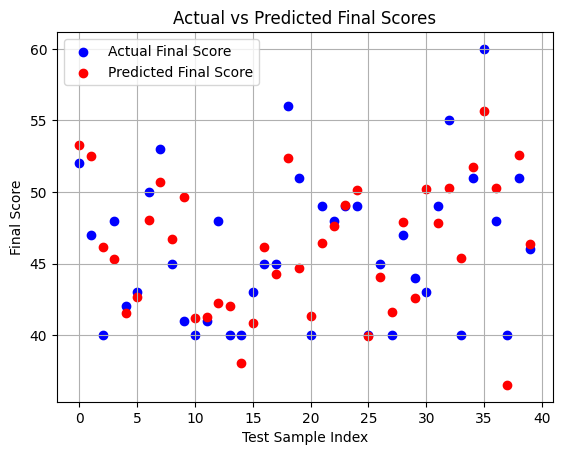

In [31]:
# Actual values (blue dots)
plt.scatter(range(len(y_test)), y_test, color='blue', label='Actual Final Score')

# Predicted values (red dots)
plt.scatter(range(len(y_pred)), y_pred, color='red', label='Predicted Final Score')

# Labels and title
plt.xlabel("Test Sample Index")
plt.ylabel("Final Score")
plt.title("Actual vs Predicted Final Scores")
plt.legend()
plt.grid(True)
plt.show() # Plotting the scatter plot

In [28]:
# This scatter plot clearly demonstrates the values predicted by the model corresponding to the actual values.
# We can clearly see that at some places both overlap or are close to each other 
# while on other places it completely missed the mark. 

In [29]:
## Conclusion Paragraph

# The Linear Regression model predicts student final scores based on features such as study hours, assignments, quizzes, midterm scores,
# and encoded categorical data. 
# The model achieved an R² value of 0.6, indicating that it explains approximately ~60% of the variance in student performance.
# Key features like attendance percentage, midterms and study hours had the strongest positive impact on predicted scores. 
# While the predictions are generally close to actual scores (MAE = 2.4, RMSE = 3.2), 
# further improvements could be made by including additional predictive factors, exploring non-linear relationships,
# or using more advanced regression techniques.